---
## 1. Setup & Imports

In [4]:
import sys
import importlib
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
import json
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')

# Import and reload our StatsBomb client to ensure latest code
import src.ingestion.statsbomb_client as sb_client
importlib.reload(sb_client)
from src.ingestion.statsbomb_client import StatsBombClient

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ Imports complete")

✓ Imports complete


---
## 2. Initialize StatsBomb Client

In [5]:
# Initialize the StatsBomb client
client = StatsBombClient()

print("✓ StatsBomb client initialized")
print(f"  Base URL: {client.base_url}")

✓ StatsBomb client initialized
  Base URL: https://raw.githubusercontent.com/statsbomb/open-data/master/data/


---
## 3. Discover Available Competitions

In [6]:
# Get all available competitions
competitions = client.get_competitions()

print(f"Found {len(competitions)} competitions\n")

# Convert to DataFrame for easier analysis
comp_df = pd.DataFrame(competitions)
comp_df.head(20)

Found 75 competitions



,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413


In [7]:
# Summarize by competition name
comp_summary = comp_df.groupby('competition_name').agg({
    'season_name': 'count',
    'competition_id': 'first'
}).rename(columns={'season_name': 'num_seasons'}).reset_index()

comp_summary = comp_summary.sort_values('num_seasons', ascending=False)

print("\nCompetitions by Number of Available Seasons:")
print("=" * 60)
comp_summary


Competitions by Number of Available Seasons:


,competition_name,num_seasons,competition_id
2,Champions League,18,16
9,La Liga,18,11
7,FIFA World Cup,8,43
4,Copa del Rey,3,87
11,Ligue 1,3,7
5,FA Women's Super League,3,37
20,Women's World Cup,2,72
0,1. Bundesliga,2,9
17,UEFA Euro,2,55
10,Liga Profesional,2,81


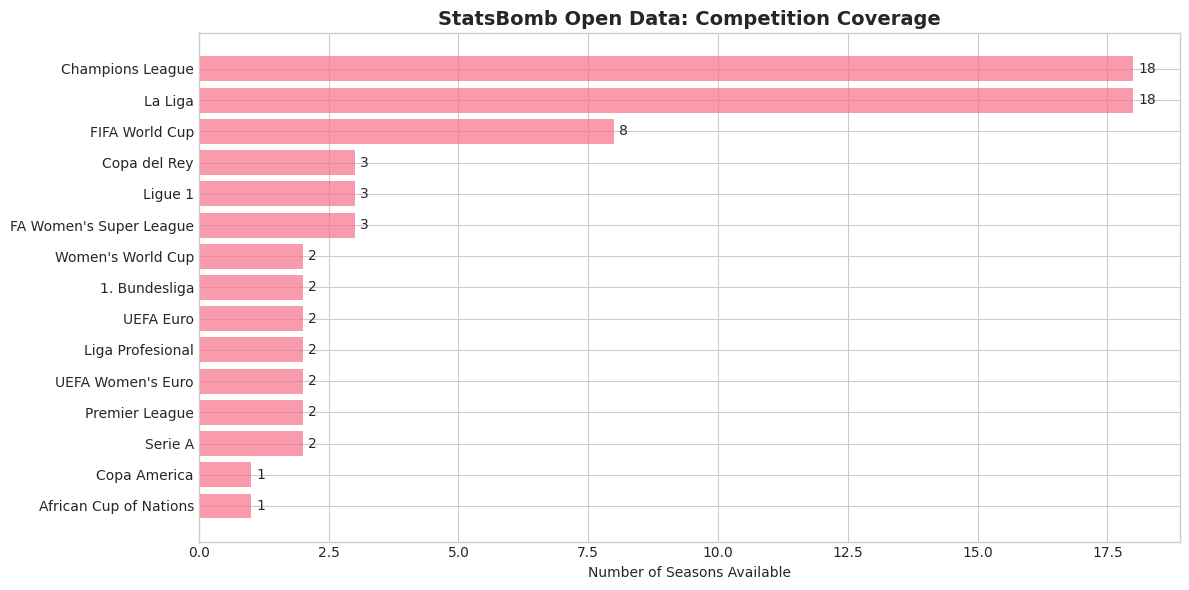

In [8]:
# Visualize competition coverage
fig, ax = plt.subplots(figsize=(12, 6))

comp_summary_top = comp_summary.head(15)
ax.barh(comp_summary_top['competition_name'], comp_summary_top['num_seasons'], alpha=0.7)
ax.set_xlabel('Number of Seasons Available')
ax.set_title('StatsBomb Open Data: Competition Coverage', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, v in enumerate(comp_summary_top['num_seasons']):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

---
## 4. Explore Target Competitions

Focus on competitions relevant to our research:
- **La Liga** (Spanish domestic league)
- **Premier League** (English domestic league)
- **Champions League** (already partially ingested)
- **Bundesliga** (German domestic league)
- **Serie A** (Italian domestic league)

In [9]:
# Filter for target competitions
target_competitions = [
    'La Liga',
    'Premier League', 
    "UEFA Champions League",
    '1. Bundesliga',
    'Serie A'
]

target_comp_df = comp_df[comp_df['competition_name'].isin(target_competitions)].copy()
target_comp_df = target_comp_df.sort_values(['competition_name', 'season_name'])

print(f"Target competitions found: {target_comp_df['competition_name'].nunique()}")
print(f"Total season-competition pairs: {len(target_comp_df)}\n")

target_comp_df[['competition_id', 'competition_name', 'season_id', 'season_name', 
                'country_name', 'competition_gender']]

Target competitions found: 4
Total season-competition pairs: 24



,competition_id,competition_name,season_id,season_name,country_name,competition_gender
1,9,1. Bundesliga,27,2015/2016,Germany,male
0,9,1. Bundesliga,281,2023/2024,Germany,male
55,11,La Liga,278,1973/1974,Spain,male
54,11,La Liga,37,2004/2005,Spain,male
53,11,La Liga,38,2005/2006,Spain,male
52,11,La Liga,39,2006/2007,Spain,male
51,11,La Liga,40,2007/2008,Spain,male
50,11,La Liga,41,2008/2009,Spain,male
49,11,La Liga,21,2009/2010,Spain,male
48,11,La Liga,22,2010/2011,Spain,male


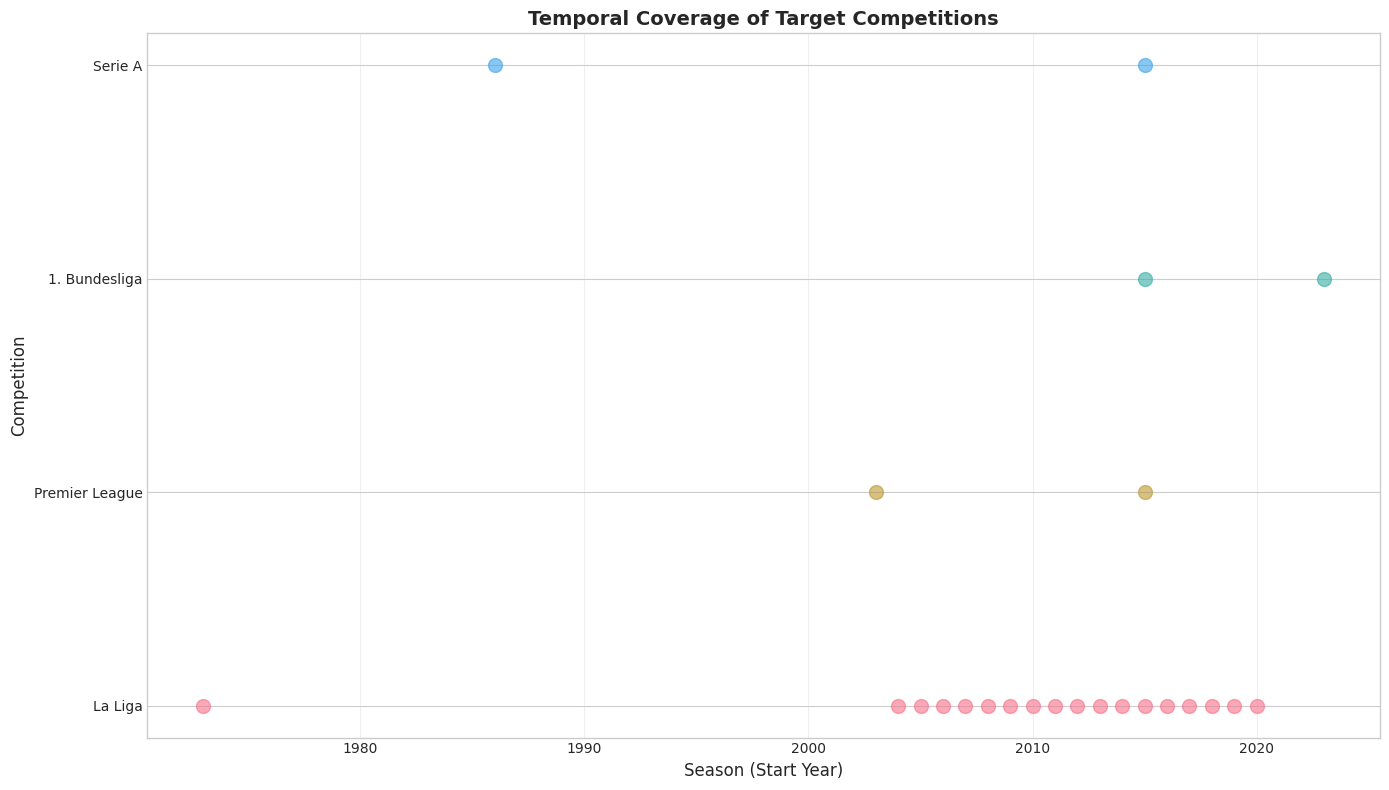

In [10]:
# Visualize temporal coverage for target competitions
fig, ax = plt.subplots(figsize=(14, 8))

for comp_name in target_competitions:
    comp_data = target_comp_df[target_comp_df['competition_name'] == comp_name]
    seasons = comp_data['season_name'].tolist()
    
    # Extract start years for plotting
    years = []
    for s in seasons:
        if '/' in str(s):
            years.append(int(s.split('/')[0]))
        else:
            try:
                years.append(int(s))
            except:
                years.append(2000)  # fallback
    
    ax.scatter(years, [comp_name] * len(years), s=100, alpha=0.6)

ax.set_xlabel('Season (Start Year)', fontsize=12)
ax.set_ylabel('Competition', fontsize=12)
ax.set_title('Temporal Coverage of Target Competitions', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Detailed Match Analysis by Competition

In [11]:
# For each target competition-season, get match counts
match_counts = []

print("Fetching match data for target competitions...\n")

for idx, row in target_comp_df.iterrows():
    comp_id = row['competition_id']
    season_id = row['season_id']
    comp_name = row['competition_name']
    season_name = row['season_name']
    
    try:
        matches = client.get_matches(competition_id=comp_id, season_id=season_id)
        num_matches = len(matches)
        
        match_counts.append({
            'competition_id': comp_id,
            'competition_name': comp_name,
            'season_id': season_id,
            'season_name': season_name,
            'num_matches': num_matches,
            'status': 'available'
        })
        
        print(f"✓ {comp_name} {season_name}: {num_matches} matches")
        
    except Exception as e:
        match_counts.append({
            'competition_id': comp_id,
            'competition_name': comp_name,
            'season_id': season_id,
            'season_name': season_name,
            'num_matches': 0,
            'status': f'error: {str(e)[:50]}'
        })
        print(f"✗ {comp_name} {season_name}: Error")

match_count_df = pd.DataFrame(match_counts)
print(f"\n✓ Fetched match counts for {len(match_count_df)} competition-season pairs")

Fetching match data for target competitions...

✓ 1. Bundesliga 2015/2016: 306 matches
✓ 1. Bundesliga 2023/2024: 34 matches
✓ La Liga 1973/1974: 1 matches
✓ 1. Bundesliga 2023/2024: 34 matches
✓ La Liga 1973/1974: 1 matches
✓ La Liga 2004/2005: 7 matches
✓ La Liga 2005/2006: 17 matches
✓ La Liga 2004/2005: 7 matches
✓ La Liga 2005/2006: 17 matches
✓ La Liga 2006/2007: 26 matches
✓ La Liga 2007/2008: 28 matches
✓ La Liga 2006/2007: 26 matches
✓ La Liga 2007/2008: 28 matches
✓ La Liga 2008/2009: 31 matches
✓ La Liga 2009/2010: 35 matches
✓ La Liga 2008/2009: 31 matches
✓ La Liga 2009/2010: 35 matches
✓ La Liga 2010/2011: 33 matches
✓ La Liga 2011/2012: 37 matches
✓ La Liga 2010/2011: 33 matches
✓ La Liga 2011/2012: 37 matches
✓ La Liga 2012/2013: 32 matches
✓ La Liga 2013/2014: 31 matches
✓ La Liga 2012/2013: 32 matches
✓ La Liga 2013/2014: 31 matches
✓ La Liga 2014/2015: 38 matches
✓ La Liga 2015/2016: 380 matches
✓ La Liga 2014/2015: 38 matches
✓ La Liga 2015/2016: 380 matches
✓ La Li

In [12]:
# Display match counts
match_count_df

,competition_id,competition_name,season_id,season_name,num_matches,status
0,9,1. Bundesliga,27,2015/2016,306,available
1,9,1. Bundesliga,281,2023/2024,34,available
2,11,La Liga,278,1973/1974,1,available
3,11,La Liga,37,2004/2005,7,available
4,11,La Liga,38,2005/2006,17,available
5,11,La Liga,39,2006/2007,26,available
6,11,La Liga,40,2007/2008,28,available
7,11,La Liga,41,2008/2009,31,available
8,11,La Liga,21,2009/2010,35,available
9,11,La Liga,22,2010/2011,33,available


In [13]:
# Summary statistics by competition
comp_match_summary = match_count_df.groupby('competition_name').agg({
    'num_matches': ['sum', 'mean', 'min', 'max'],
    'season_name': 'count'
}).round(1)

comp_match_summary.columns = ['total_matches', 'avg_matches_per_season', 'min_matches', 'max_matches', 'num_seasons']
comp_match_summary = comp_match_summary.sort_values('total_matches', ascending=False)

print("\nMatch Count Summary by Competition:")
print("=" * 80)
comp_match_summary


Match Count Summary by Competition:


,total_matches,avg_matches_per_season,min_matches,max_matches,num_seasons
competition_name,,,,,
La Liga,868,48.2,1,380,18
Premier League,418,209.0,38,380,2
Serie A,381,190.5,1,380,2
1. Bundesliga,340,170.0,34,306,2


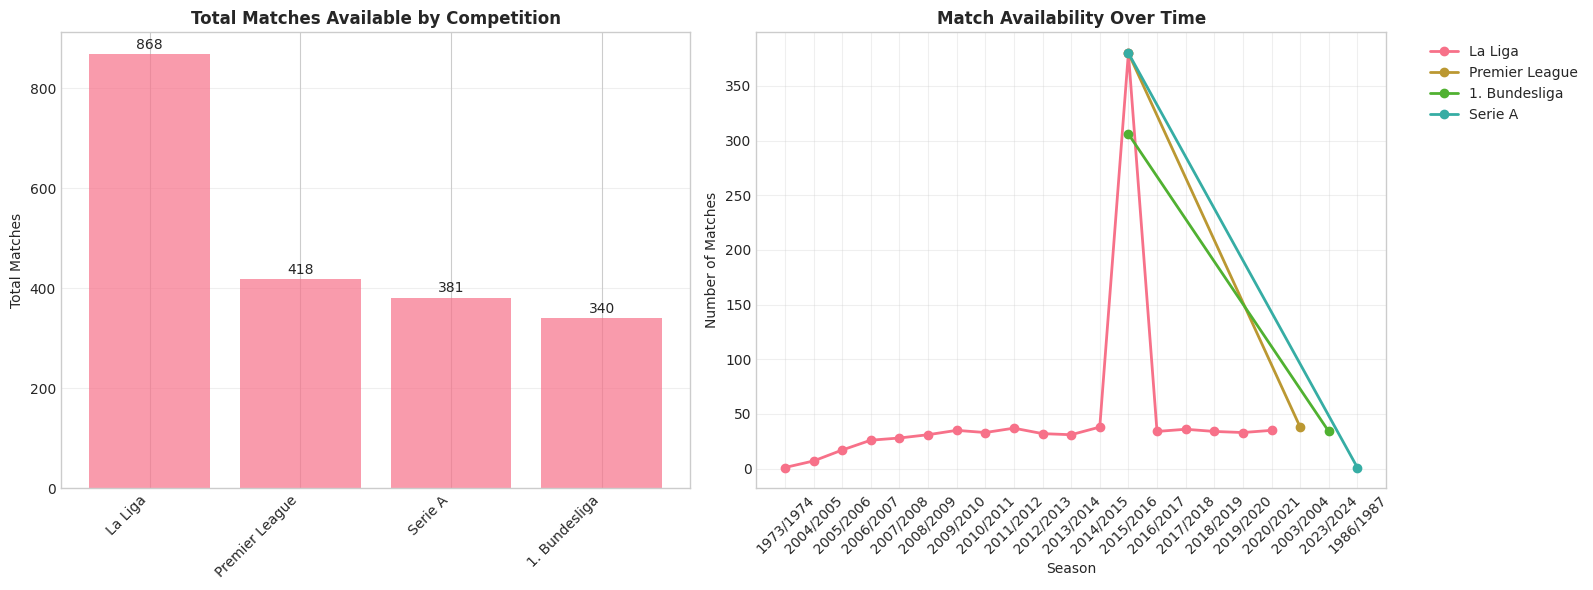

In [14]:
# Visualize match availability
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total matches per competition
ax1 = axes[0]
comp_totals = match_count_df.groupby('competition_name')['num_matches'].sum().sort_values(ascending=False)
ax1.bar(range(len(comp_totals)), comp_totals.values, alpha=0.7)
ax1.set_xticks(range(len(comp_totals)))
ax1.set_xticklabels(comp_totals.index, rotation=45, ha='right')
ax1.set_ylabel('Total Matches')
ax1.set_title('Total Matches Available by Competition', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(comp_totals.values):
    ax1.text(i, v + 5, str(v), ha='center', va='bottom')

# Matches per season over time
ax2 = axes[1]
for comp_name in target_competitions:
    comp_data = match_count_df[match_count_df['competition_name'] == comp_name]
    if len(comp_data) > 0:
        ax2.plot(comp_data['season_name'], comp_data['num_matches'], 
                marker='o', label=comp_name, linewidth=2, markersize=6)

ax2.set_xlabel('Season')
ax2.set_ylabel('Number of Matches')
ax2.set_title('Match Availability Over Time', fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Sample Match Deep Dive

Examine a sample match to understand event data quality and coverage.

In [15]:
# Get a sample match from La Liga (if available)
la_liga_data = match_count_df[
    (match_count_df['competition_name'] == 'La Liga') & 
    (match_count_df['num_matches'] > 0)
]

if len(la_liga_data) > 0:
    sample_comp_id = la_liga_data.iloc[0]['competition_id']
    sample_season_id = la_liga_data.iloc[0]['season_id']
    sample_season_name = la_liga_data.iloc[0]['season_name']
    
    print(f"Fetching matches from La Liga {sample_season_name}...")
    sample_matches = client.get_matches(competition_id=sample_comp_id, season_id=sample_season_id)
    
    if len(sample_matches) > 0:
        sample_match = sample_matches[0]
        sample_match_id = sample_match['match_id']
        
        print(f"\nSample Match Details:")
        print(f"  Match ID: {sample_match_id}")
        print(f"  Home: {sample_match.get('home_team', {}).get('home_team_name', 'N/A')}")
        print(f"  Away: {sample_match.get('away_team', {}).get('away_team_name', 'N/A')}")
        print(f"  Date: {sample_match.get('match_date', 'N/A')}")
        print(f"  Score: {sample_match.get('home_score', 'N/A')} - {sample_match.get('away_score', 'N/A')}")
else:
    print("No La Liga data available, trying Champions League...")
    ucl_data = match_count_df[
        (match_count_df['competition_name'] == 'UEFA Champions League') & 
        (match_count_df['num_matches'] > 0)
    ]
    
    if len(ucl_data) > 0:
        sample_comp_id = ucl_data.iloc[0]['competition_id']
        sample_season_id = ucl_data.iloc[0]['season_id']
        sample_season_name = ucl_data.iloc[0]['season_name']
        
        print(f"Fetching matches from Champions League {sample_season_name}...")
        sample_matches = client.get_matches(competition_id=sample_comp_id, season_id=sample_season_id)
        
        if len(sample_matches) > 0:
            sample_match = sample_matches[0]
            sample_match_id = sample_match['match_id']

Fetching matches from La Liga 1973/1974...

Sample Match Details:
  Match ID: 3888713
  Home: Real Madrid
  Away: Barcelona
  Date: 1974-02-17
  Score: 0 - 5


In [16]:
# Get events for the sample match
if 'sample_match_id' in locals():
    print(f"Fetching events for match {sample_match_id}...\n")
    sample_events = client.get_events(match_id=sample_match_id)
    
    print(f"Total events: {len(sample_events)}")
    
    # Convert to DataFrame
    events_df = pd.DataFrame(sample_events)
    
    # Event type breakdown
    event_type_counts = events_df['type'].value_counts()
    
    print(f"\nEvent Types (top 15):")
    print(event_type_counts.head(15))
else:
    print("No sample match available to fetch events")

Fetching events for match 3888713...

Total events: 2974

Event Types (top 15):
type
{'id': 30, 'name': 'Pass'}              778
{'id': 42, 'name': 'Ball Receipt*'}     720
{'id': 43, 'name': 'Carry'}             637
{'id': 17, 'name': 'Pressure'}          256
{'id': 2, 'name': 'Ball Recovery'}      125
{'id': 4, 'name': 'Duel'}                60
{'id': 9, 'name': 'Clearance'}           54
{'id': 14, 'name': 'Dribble'}            45
{'id': 6, 'name': 'Block'}               42
{'id': 38, 'name': 'Miscontrol'}         37
{'id': 22, 'name': 'Foul Committed'}     36
{'id': 23, 'name': 'Goal Keeper'}        33
{'id': 21, 'name': 'Foul Won'}           31
{'id': 39, 'name': 'Dribbled Past'}      29
{'id': 16, 'name': 'Shot'}               28
Name: count, dtype: int64
Total events: 2974

Event Types (top 15):
type
{'id': 30, 'name': 'Pass'}              778
{'id': 42, 'name': 'Ball Receipt*'}     720
{'id': 43, 'name': 'Carry'}             637
{'id': 17, 'name': 'Pressure'}          256
{'id':

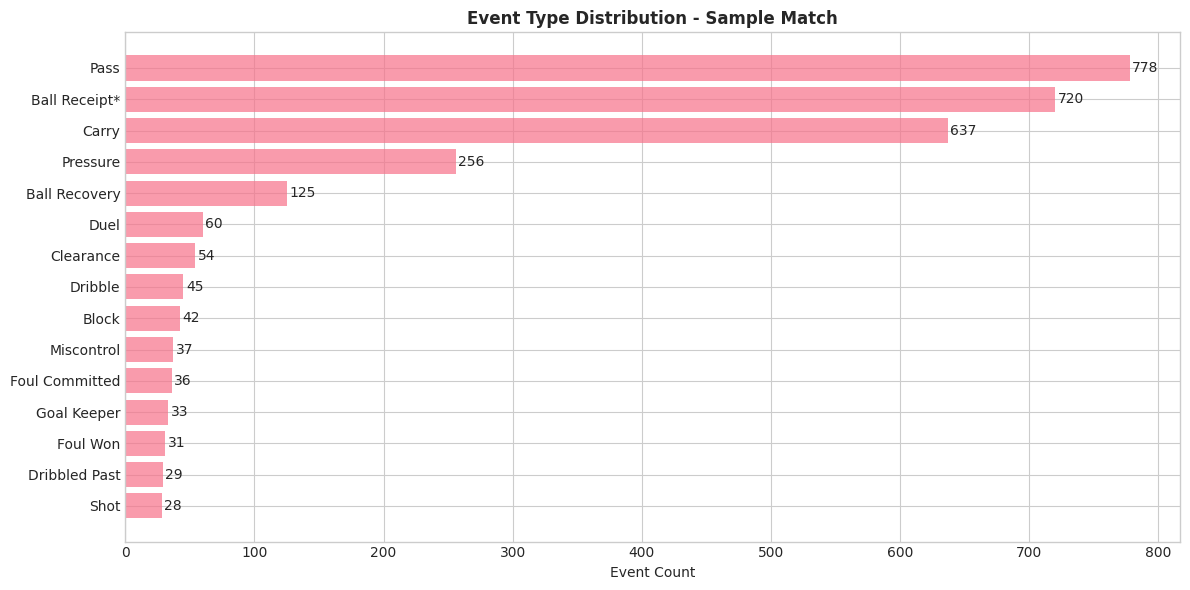

In [17]:
# Visualize event type distribution
if 'event_type_counts' in locals():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    top_events = event_type_counts.head(15)
    ax.barh(range(len(top_events)), top_events.values, alpha=0.7)
    ax.set_yticks(range(len(top_events)))
    ax.set_yticklabels([name.get('name', 'Unknown') if isinstance(name, dict) else name 
                        for name in top_events.index])
    ax.set_xlabel('Event Count')
    ax.set_title(f'Event Type Distribution - Sample Match', fontweight='bold')
    ax.invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_events.values):
        ax.text(v + 2, i, str(v), va='center')
    
    plt.tight_layout()
    plt.show()

In [18]:
# Check data completeness for key fields
if 'events_df' in locals():
    key_fields = ['timestamp', 'period', 'location', 'player', 'team', 'possession_team']
    
    completeness = {}
    for field in key_fields:
        if field in events_df.columns:
            non_null_pct = (1 - events_df[field].isna().mean()) * 100
            completeness[field] = non_null_pct
        else:
            completeness[field] = 0.0
    
    completeness_df = pd.DataFrame(list(completeness.items()), 
                                    columns=['Field', 'Completeness (%)'])
    completeness_df = completeness_df.sort_values('Completeness (%)', ascending=False)
    
    print("\nData Completeness for Key Fields:")
    print("=" * 40)
    print(completeness_df.to_string(index=False))


Data Completeness for Key Fields:
          Field  Completeness (%)
      timestamp        100.000000
         period        100.000000
possession_team        100.000000
           team        100.000000
         player         99.630128
       location         99.462004


---
## 7. Ingestion Priority Recommendations

In [19]:
# Calculate ingestion priority score
priority_df = match_count_df.copy()

# Extract start year for temporal relevance
def extract_year(season_name):
    if '/' in str(season_name):
        try:
            return int(season_name.split('/')[0])
        except:
            return 2000
    else:
        try:
            return int(season_name)
        except:
            return 2000

priority_df['start_year'] = priority_df['season_name'].apply(extract_year)

# Priority factors:
# 1. More matches = better (weight: 0.4)
# 2. More recent = better (weight: 0.3)
# 3. Target competitions = better (weight: 0.3)

# Normalize factors
max_matches = priority_df['num_matches'].max()
max_year = priority_df['start_year'].max()
min_year = priority_df['start_year'].min()

priority_df['match_score'] = priority_df['num_matches'] / max_matches
priority_df['recency_score'] = (priority_df['start_year'] - min_year) / (max_year - min_year)
priority_df['competition_score'] = priority_df['competition_name'].apply(
    lambda x: 1.0 if x == 'La Liga' else 0.8 if x in ['Premier League', 'UEFA Champions League'] else 0.6
)

# Calculate overall priority score
priority_df['priority_score'] = (
    0.4 * priority_df['match_score'] +
    0.3 * priority_df['recency_score'] +
    0.3 * priority_df['competition_score']
) * 100

priority_df = priority_df.sort_values('priority_score', ascending=False)

print("\nIngestion Priority Ranking:")
print("=" * 80)
priority_df[['competition_name', 'season_name', 'num_matches', 'start_year', 'priority_score']].head(20)


Ingestion Priority Ranking:


,competition_name,season_name,num_matches,start_year,priority_score
14,La Liga,2015/2016,380,2015,95.200000
21,Premier League,2015/2016,380,2015,89.200000
23,Serie A,2015/2016,380,2015,83.200000
0,1. Bundesliga,2015/2016,306,2015,75.410526
19,La Liga,2020/2021,35,2020,61.884211
18,La Liga,2019/2020,33,2019,61.073684
17,La Liga,2018/2019,34,2018,60.578947
16,La Liga,2017/2018,36,2017,60.189474
15,La Liga,2016/2017,34,2016,59.378947
13,La Liga,2014/2015,38,2014,58.600000


In [20]:
# Top recommendations by competition
print("\n" + "=" * 80)
print("INGESTION RECOMMENDATIONS")
print("=" * 80)

for comp_name in ['La Liga', 'Premier League', 'UEFA Champions League', '1. Bundesliga', 'Serie A']:
    comp_priority = priority_df[
        (priority_df['competition_name'] == comp_name) & 
        (priority_df['num_matches'] > 0)
    ].head(5)
    
    if len(comp_priority) > 0:
        print(f"\n{comp_name}:")
        print("-" * 60)
        total_matches = comp_priority['num_matches'].sum()
        seasons = comp_priority['season_name'].tolist()
        print(f"  Top 5 seasons: {', '.join(map(str, seasons))}")
        print(f"  Total matches: {total_matches}")
        print(f"  Avg priority: {comp_priority['priority_score'].mean():.1f}/100")


INGESTION RECOMMENDATIONS

La Liga:
------------------------------------------------------------
  Top 5 seasons: 2015/2016, 2020/2021, 2019/2020, 2018/2019, 2017/2018
  Total matches: 518
  Avg priority: 67.8/100

Premier League:
------------------------------------------------------------
  Top 5 seasons: 2015/2016, 2003/2004
  Total matches: 418
  Avg priority: 67.6/100

1. Bundesliga:
------------------------------------------------------------
  Top 5 seasons: 2015/2016, 2023/2024
  Total matches: 340
  Avg priority: 63.5/100

Serie A:
------------------------------------------------------------
  Top 5 seasons: 2015/2016, 1986/1987
  Total matches: 381
  Avg priority: 54.6/100


---
## 8. Export Results for Reference

In [21]:
# Save the analysis results
output_dir = Path('../data/exploration')
output_dir.mkdir(parents=True, exist_ok=True)

# Export competition summary
comp_match_summary.to_csv(output_dir / 'competition_summary.csv')
print(f"✓ Saved competition summary to {output_dir / 'competition_summary.csv'}")

# Export match counts
match_count_df.to_csv(output_dir / 'match_counts_by_season.csv', index=False)
print(f"✓ Saved match counts to {output_dir / 'match_counts_by_season.csv'}")

# Export priority rankings
priority_df.to_csv(output_dir / 'ingestion_priorities.csv', index=False)
print(f"✓ Saved priority rankings to {output_dir / 'ingestion_priorities.csv'}")

print("\n✓ All exploration data exported successfully")

✓ Saved competition summary to ../data/exploration/competition_summary.csv
✓ Saved match counts to ../data/exploration/match_counts_by_season.csv
✓ Saved priority rankings to ../data/exploration/ingestion_priorities.csv

✓ All exploration data exported successfully


---
## 9. Summary & Next Steps

In [ ]:
print("\n" + "=" * 80)
print("EXPLORATION SUMMARY")
print("=" * 80)

total_available_matches = match_count_df['num_matches'].sum()
total_competitions = match_count_df['competition_name'].nunique()
total_seasons = len(match_count_df)

print(f"\nTotal Available Data:")
print(f"  • Competitions: {total_competitions}")
print(f"  • Competition-Season pairs: {total_seasons}")
print(f"  • Total matches: {total_available_matches}")

# La Liga specific
la_liga_matches = match_count_df[match_count_df['competition_name'] == 'La Liga']['num_matches'].sum()
la_liga_seasons = len(match_count_df[match_count_df['competition_name'] == 'La Liga'])

print(f"\nLa Liga (Primary Target):")
print(f"  • Seasons available: {la_liga_seasons}")
print(f"  • Total matches: {la_liga_matches}")
print(f"  • Est. team-match records: {la_liga_matches * 2}")

# Current dataset comparison
current_matches = 278 / 2  # Current team-match records / 2
improvement_factor = (la_liga_matches / current_matches) if current_matches > 0 else 0

print(f"\nImpact Analysis:")
print(f"  • Current dataset: ~{int(current_matches)} matches")
print(f"  • With La Liga: ~{int(la_liga_matches)} matches")
print(f"  • Improvement factor: {improvement_factor:.1f}x")

print("\n" + "=" * 80)
print("RECOMMENDATION: Proceed with La Liga ingestion for Phase 4 modeling")
print("=" * 80)